<>:76: SyntaxWarning: invalid escape sequence '\s'
<>:76: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_507/2964128822.py:76: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Estimated coefficients:
b_0 = 1.2363636363636363
b_1 = 1.1696969696969697


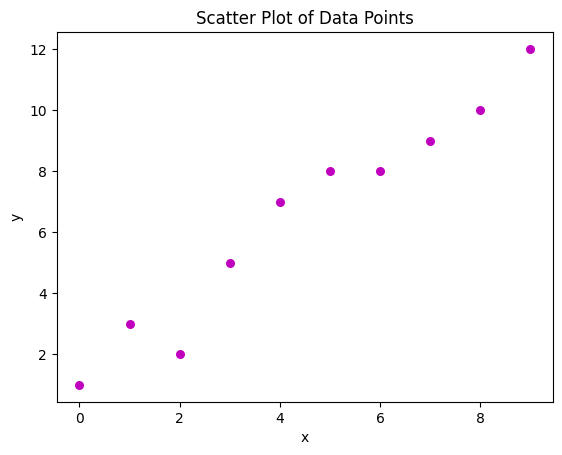

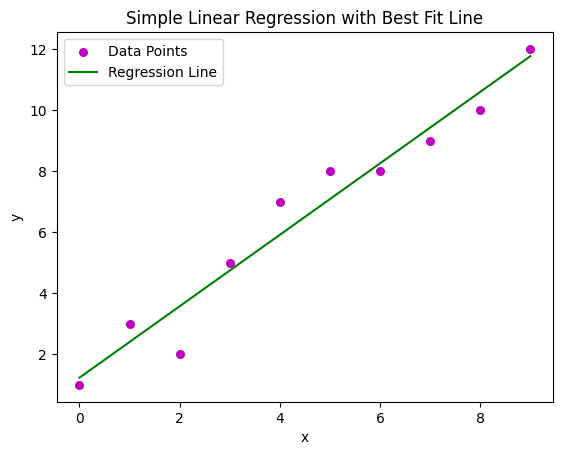

Coefficients:  [-8.95714048e-02  6.73132853e-02  5.04649248e-02  2.18579583e+00
 -1.72053975e+01  3.63606995e+00  2.05579939e-03 -1.36602886e+00
  2.89576718e-01 -1.22700072e-02 -8.34881849e-01  9.40360790e-03
 -5.04008320e-01]
Variance score: 0.720905667266174


Text(0.5, 1.0, 'Residual errors')

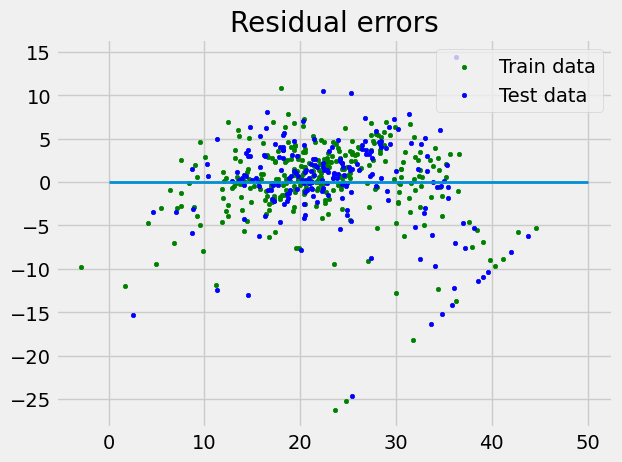

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def estimate_coef(x, y):
# number of observations/points
  n = np.size(x)

# mean of x and y vector
  m_x = np.mean(x)
  m_y = np.mean(y)

# calculating cross-deviation and deviation about x
  SS_xy = np.sum(y*x) - n*m_y*m_x
  SS_xx = np.sum(x*x) - n*m_x*m_x

# calculating regression coefficients
  b_1 = SS_xy / SS_xx
  b_0 = m_y - b_1*m_x

  return (b_0, b_1)


def plot_scatter_only(x, y):
# plotting the actual points as scatter plot
  plt.scatter(x, y, color = "m",
     marker = "o", s = 30)

# putting labels
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title('Scatter Plot of Data Points') # Title for scatter plot
  plt.show() # Display the scatter plot

def plot_scatter_and_regression_line(x, y, b):
# Re-plotting scatter for context in the regression line plot
  plt.scatter(x, y, color = "m",
     marker = "o", s = 30, label='Data Points')

# predicted response vector
  y_pred = b[0] + b[1]*x

# plotting the regression line
  plt.plot(x, y_pred, color = "g", label='Regression Line')

# putting labels
  plt.xlabel('x')
  plt.ylabel('y')
  plt.title('Simple Linear Regression with Best Fit Line') # Title for regression line plot
  plt.legend() # Show legend for labels
  plt.show() # Display the regression line plot

def main():
# observations / data
  x = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
  y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 12])

# estimating coefficients
  b = estimate_coef(x, y)
  print("Estimated coefficients:\nb_0 = {}\nb_1 = {}".format(b[0], b[1]))

# plotting scatter points first
  plot_scatter_only(x, y)

# then plotting regression line (with scatter for context)
  plot_scatter_and_regression_line(x, y, b)


main() # Call the main function to execute the code
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, linear_model, metrics
import pandas as pd

data_url = "https://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)

X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y = raw_df.values[1::2, 2]

X_train, X_test,\
  y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=1)

reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)

# regression coefficients
print('Coefficients: ', reg.coef_)

# variance score: 1 means perfect prediction
print('Variance score: {}'.format(reg.score(X_test, y_test)))


# plot for residual error

# setting plot style
plt.style.use('fivethirtyeight')

# plotting residual errors in training data
plt.scatter(reg.predict(X_train),
            reg.predict(X_train) - y_train,
            color="green", s=10,
            label='Train data')

# plotting residual errors in test data
plt.scatter(reg.predict(X_test),
            reg.predict(X_test) - y_test,
            color="blue", s=10,
            label='Test data')

# plotting line for zero residual error
plt.hlines(y=0, xmin=0, xmax=50, linewidth=2)

# plotting legend
plt.legend(loc='upper right')

# plot title
plt.title("Residual errors")

In [3]:
raw_df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8
